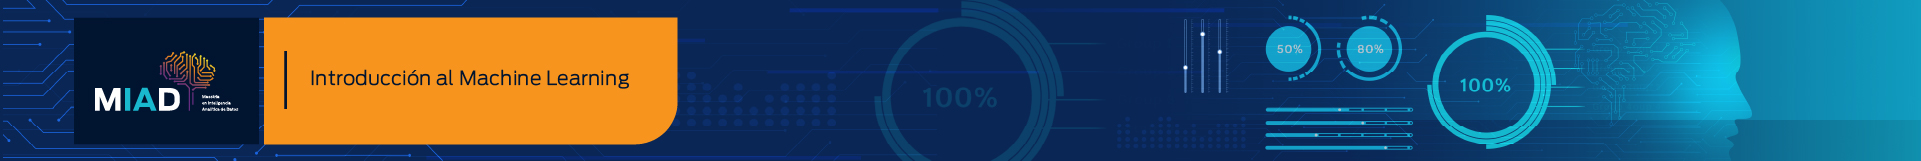

# Introducción al Machine Learning - Semana 7
## Caso: Implementación de metodologías de máquinas de soporte vectorial, el uso de kernels y selección de variables

### Propósito de la actividad

En esta actividad podrán poner en práctica, con un conjunto de datos reales, su habilidad para implementar máquinas de soporte vectorial y la implementación de metodologías de selección de variables. Con respecto a las máquinas de soporte vectorial, estas deberán implementarse de tres maneras:sin kernel, con kernel polinomial y con kernel radial.

Además, como en todo procedimiento de analítica de datos, se evaluará la exploración preliminar de los datos por medio de herramientas como histogramas, correlogramas y estadísticas descriptivas.

### Instrucciones generales

1. Los procedimientos en este notebook deberán responderse en los espacios especificados para tal fin, debajo de cada uno de los puntos.

2. Para su calificación deberá subirse únicamente este mismo archivo en formato HTML.

3. El archivo debe poder ejecutarse localmente cuando sea descargado, asumiendo que la base de datos de la actividad ya ha sido importada en el correspondiente archivo separado por comas (.csv).

### Criterios de evaluación

Los criterios que se evaluarán son: 

Análisis preliminar de variables: Se presentan correlogramas, histogramas y estadísticas descriptivas de las variables de la base de datos y se hace un análisis coherente de cada uno de ellos. [5 puntos] 

Estimación de modelo SVM de clasificación: Se estima un modelo SVM de clasificación, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [10 puntos] 

Selección de variables usando métodos de envoltura e implementación de modelo de clasificación: Se estima un modelo SVM con las variables seleccionadas usando un método de envoltura, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos] 

Selección de variables usando métodos de filtro e implementación de modelo de clasificación: Se estima un modelo SVM con las variables seleccionadas usando un método de filtro, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos] 

Estimación de modelo SVM de clasificación con kernel polinomial: Se estima un modelo SVM de clasificación con kernel polinomial, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos] 

Estimación de modelo SVM de clasificación con kernel radial: Se estima un modelo SVM de clasificación con kernel radial, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos] 

Elección del mejor modelo: Se elige el mejor modelo de acuerdo a los resultados obtenidos y se justifica adecuadamente la elección. [5 puntos] 

### Datos

En esta ocasión usarán una base de datos disponible en la página R-Data. Esta base de datos corresponde a "Hitters", la cual contiene 20 variables de jugadores de la Major League Baseball en las temporadas de 1986 y 1987. 

De esta manera, el objetivo de la actividad es predecir si el salario de un jugador es mayor a 425 utiilzando las características que describen las variables predictivas.

Por lo anterior, en primer lugar deberán descargar la base de datos del siguiente enlace: https://r-data.pmagunia.com/dataset/r-dataset-package-islr-hitters

Finalmente, para resolver los puntos de esta actividad deberán tener en cuenta únicamente las variables continuas (se deben eliminar las variables categóricas) y deberán eliminar las observaciones con datos faltantes.

In [1]:
#  Cargar librerías
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.feature_selection import RFE


In [2]:
#Cargar datos
df = pd.read_csv("Hitters.csv", sep=",")
df

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,-Willie McGee,497,127,7,65,48,37,5,2703,806,...,379,311,138,N,E,325,9,3,700.0,N
318,-Willie Randolph,492,136,5,76,50,94,12,5511,1511,...,897,451,875,A,E,313,381,20,875.0,A
319,-Wayne Tolleson,475,126,3,61,43,52,6,1700,433,...,217,93,146,A,W,37,113,7,385.0,A
320,-Willie Upshaw,573,144,9,85,60,78,8,3198,857,...,470,420,332,A,E,1314,131,12,960.0,A


In [3]:
# Se eliminar filas con valores faltantes en la columna 'Salary' ya que es la columna que se debe predecir y la variable de nombre ya que esta no afecta el modelo por se unica para identificar cada fila
df.dropna(subset=['Salary'], inplace=True)
df.reset_index(drop=True, inplace=True)
# variable de respuesta binaria
ytotal = (df['Salary'] > 425).astype(int)
Xtotal = df.drop(columns=['Salary', 'Unnamed: 0','League','Division','NewLeague'])

In [4]:
#División de train y test con 33% en test
XTrain, XTest, yTrain, yTest = train_test_split(Xtotal, ytotal, test_size=0.33, random_state=0)

### 1. Análisis preliminar de variables (5 puntos)
Realicen un análisis preliminar de los predictores y de la variable de respuesta (correlogramas, histogramas y estadísticas descriptivas).

=== Estadísticas descriptivas de los predictores ===


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
count,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
mean,403.642586,107.828897,11.619772,54.745247,51.486692,41.114068,7.311787,2657.543726,722.186312,69.239544,361.220532,330.418251,260.266160,290.711027,118.760456,8.593156
std,147.307209,45.125326,8.757108,25.539816,25.882714,21.718056,4.793616,2286.582929,648.199644,82.197581,331.198571,323.367668,264.055868,279.934575,145.080577,6.606574
min,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.000000,4.000000,0.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000
25%,282.500000,71.500000,5.000000,33.500000,30.000000,23.000000,4.000000,842.500000,212.000000,15.000000,105.500000,95.000000,71.000000,113.500000,8.000000,3.000000
50%,413.000000,103.000000,9.000000,52.000000,47.000000,37.000000,6.000000,1931.000000,516.000000,40.000000,250.000000,230.000000,174.000000,224.000000,45.000000,7.000000
75%,526.000000,141.500000,18.000000,73.000000,71.000000,57.000000,10.000000,3890.500000,1054.000000,92.500000,497.500000,424.500000,328.500000,322.500000,192.000000,13.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1377.000000,492.000000,32.000000



=== Distribución de la variable de respuesta (Salary > 425) ===
Salary
0    134
1    129
Name: count, dtype: int64

Proporción clase 1 (Salary > 425): 49.05%


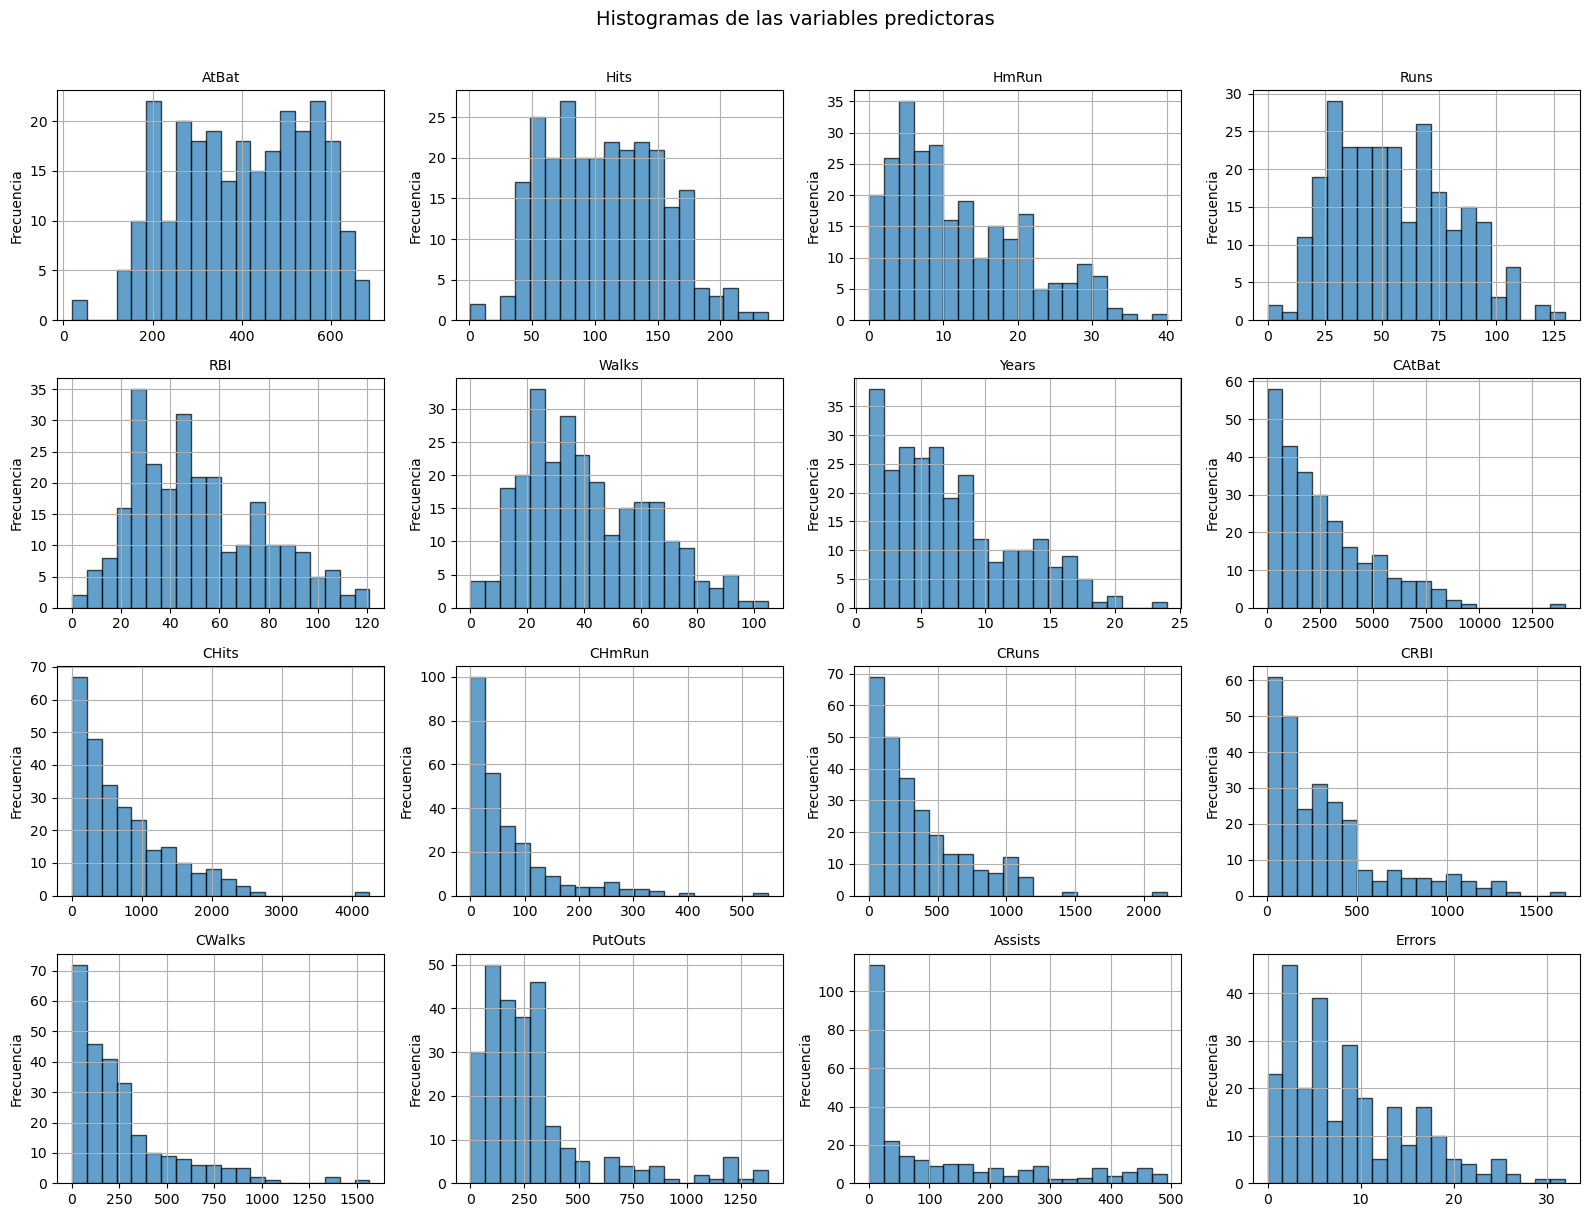

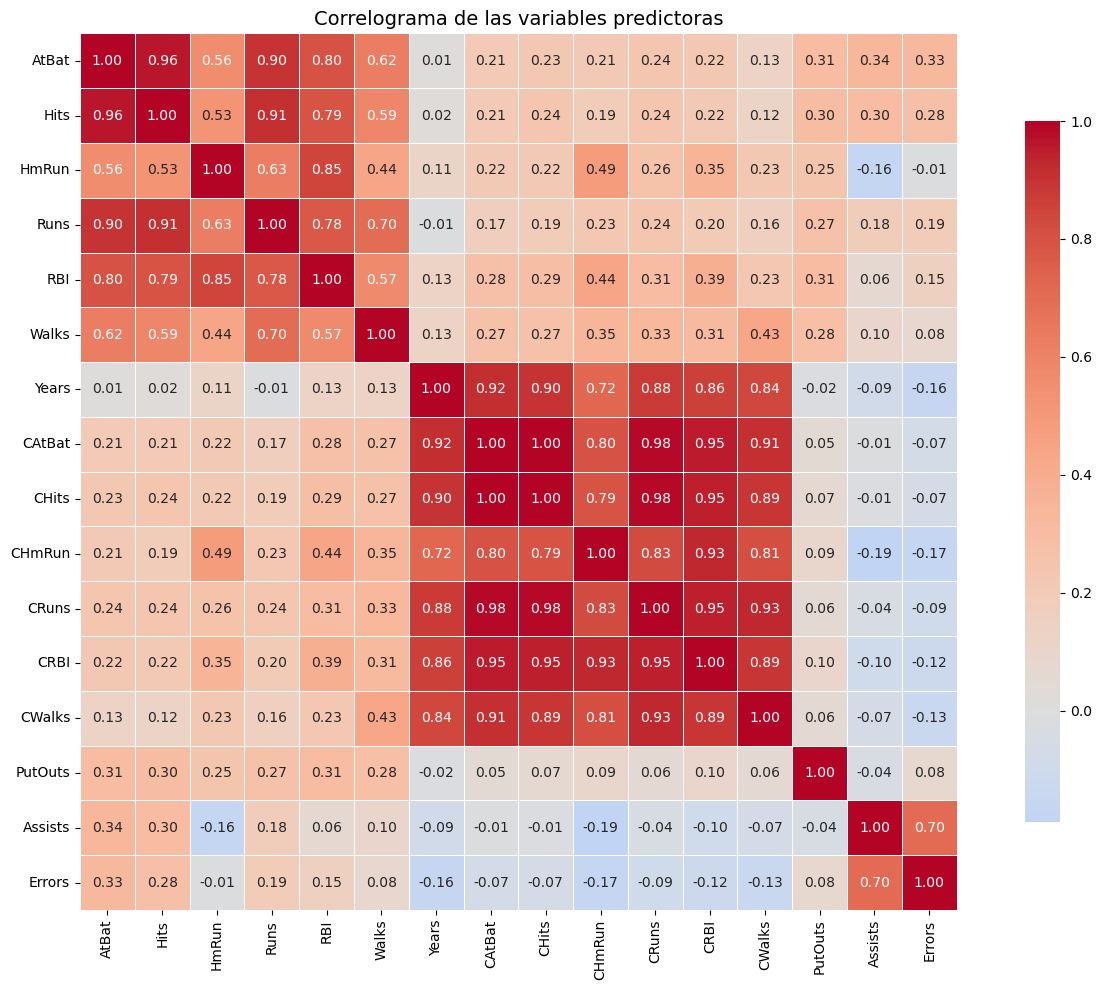

In [5]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 1 ####

# Estadísticas descriptivas de los predictores
print("=== Estadísticas descriptivas de los predictores ===")
display(Xtotal.describe())

# Balance de la variable de respuesta
print("\n=== Distribución de la variable de respuesta (Salary > 425) ===")
print(ytotal.value_counts())
print(f"\nProporción clase 1 (Salary > 425): {ytotal.mean():.2%}")

# Histogramas de las variables continuas
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(Xtotal.columns):
    Xtotal[col].hist(ax=axes[i], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frecuencia')
plt.suptitle('Histogramas de las variables predictoras', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Correlograma (mapa de calor de correlaciones)
plt.figure(figsize=(14, 10))
corr_matrix = Xtotal.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlograma de las variables predictoras', fontsize=14)
plt.tight_layout()
plt.show()



**Analisis y conclusiones del Punto 1:**

**Estadisticas descriptivas:** Se observa que las variables tienen escalas muy diferentes entre si. Por ejemplo, `AtBat` tiene un rango de 16 a 687, mientras que `Years` va de 1 a 24. Variables acumuladas como `CAtBat`, `CHits`, `CRuns`, `CRBI` y `CWalks` presentan valores mucho mas altos que sus contrapartes de temporada individual, lo cual es esperado ya que representan totales de carrera. La mayoria de las distribuciones presentan asimetria positiva (sesgo a la derecha), especialmente las variables de carrera.

**Histogramas:** Las variables de carrera (`CAtBat`, `CHits`, `CRuns`, `CRBI`, `CWalks`) muestran distribuciones marcadamente sesgadas a la derecha, indicando que la mayoria de jugadores tienen valores bajos y unos pocos tienen valores muy altos (jugadores veteranos). Las variables de temporada individual (`AtBat`, `Hits`, `Runs`, `RBI`, `Walks`) presentan distribuciones mas simetricas. La variable `Years` tiene una distribucion relativamente uniforme.

**Correlograma:** Se identifican correlaciones muy altas (>0.90) entre las variables de carrera: `CAtBat`-`CHits` (0.97), `CAtBat`-`CRuns` (0.95), `CHits`-`CRuns` (0.97), lo cual indica alta multicolinealidad. Las variables de temporada individual tambien muestran correlaciones moderadas a altas entre si. Esto sugiere que la seleccion de variables sera importante para reducir la redundancia y mejorar el rendimiento del modelo SVM.

**Balance de clases:** La variable de respuesta (Salary > 425) muestra un balance razonable entre las dos clases, lo cual es favorable para la clasificacion.

### 2. Estimación de modelo SVM de clasificación (10 puntos)
Estimen un modelo de support vector machine sin kernel con la muestra de entrenamiento y calculen su poder predictivo evaluándolo en la muestra de test.

In [12]:
kf = KFold(n_splits=10)

auc_folds = []
acc_folds = []
precision_folds = []
recall_folds = []
f1_folds = []

for train_idx, test_idx in kf.split(Xtotal):
    X_trainCV, X_testCV = Xtotal.iloc[train_idx], Xtotal.iloc[test_idx]
    y_trainCV, y_testCV = ytotal.iloc[train_idx], ytotal.iloc[test_idx]
    clf = SVC(probability=True).fit(X_trainCV, y_trainCV)
    
    scores = clf.predict_proba(X_testCV)[:, 1]
    preds = clf.predict(X_testCV)

    auc_folds.append(metrics.roc_auc_score(y_testCV, scores))
    acc_folds.append(metrics.accuracy_score(y_testCV, preds))
    precision_folds.append(metrics.precision_score(y_testCV, preds))
    recall_folds.append(metrics.recall_score(y_testCV, preds))
    f1_folds.append(metrics.f1_score(y_testCV, preds))

    auc_svm = np.mean(auc_folds)
    acc_svm = np.mean(acc_folds)

print("AUC promedio:", np.mean(auc_folds))
print("Accuracy promedio:", np.mean(acc_folds))
print("Precision promedio:", np.mean(precision_folds))
print("Recall promedio:", np.mean(recall_folds))
print("F1 promedio:", np.mean(f1_folds))



AUC promedio: 0.9051554282332941
Accuracy promedio: 0.8289173789173789
Precision promedio: 0.8154308926367749
Recall promedio: 0.8571171802054156
F1 promedio: 0.8176126887536623


(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 2)

### 3. Selección de variables usando métodos de envoltura e implementación de modelo de clasificación (20 puntos)
Realicen una selección de variables utilizando un algoritmo de envoltura y establezcan claramente las variables que se seleccionaron. Luego, calibren el modelo SVM únicamente con las variables seleccionadas y midan su desempeño en la muestra de evaluación.

In [7]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 3 ####

estimator = SVC(kernel='linear',probability=True)  
selector = RFE(estimator, n_features_to_select=int(XTrain.shape[1] / 2), step=1) #Se define step=1, pero lo puede cambiar para que sea más rápido
selector = selector.fit(XTrain, yTrain) # esto puede tardar algunos minutos

selector.support_  #Conjunto de variables seleccionadas

array([False, False,  True,  True, False,  True,  True, False,  True,
        True, False,  True, False, False, False,  True])

In [8]:
result = pd.DataFrame({
    "variable": XTrain.columns,
    "selected": selector.support_
})
selected_features = XTrain.columns[selector.support_]
selected_features
result
XTrain_sel = XTrain[selected_features]
XTest_sel = XTest[selected_features]

In [13]:
kf = KFold(n_splits=10)


auc_folds2 = []
acc_folds2 = []
precision_folds2 = []
recall_folds2 = []
f1_folds2 = []

for train_idx, val_idx in kf.split(XTrain_sel):
    X_tr, X_val = XTrain_sel.iloc[train_idx], XTrain_sel.iloc[val_idx]
    y_tr, y_val = yTrain.iloc[train_idx], yTrain.iloc[val_idx]

    clf = SVC(kernel="linear", probability=True, random_state=0)
    clf.fit(X_tr, y_tr)

    scores = clf.predict_proba(X_val)[:, 1]
    preds = clf.predict(X_val)

    auc_folds2.append(metrics.roc_auc_score(y_val, scores))
    acc_folds2.append(metrics.accuracy_score(y_val, preds))
    precision_folds2.append(metrics.precision_score(y_val, preds))
    recall_folds2.append(metrics.recall_score(y_val, preds))
    f1_folds2.append(metrics.f1_score(y_val, preds))

auc_meim = np.mean(auc_folds2)
acc_meim = np.mean(acc_folds2)

print("AUC promedio:", np.mean(auc_folds2))
print("Accuracy promedio:", np.mean(acc_folds2))
print("Precision promedio:", np.mean(precision_folds2))
print("Recall promedio:", np.mean(recall_folds2))
print("F1 promedio:", np.mean(f1_folds2))

AUC promedio: 0.897020202020202
Accuracy promedio: 0.8245098039215686
Precision promedio: 0.815981240981241
Recall promedio: 0.8171717171717171
F1 promedio: 0.807026803605751


(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 3)

### 4. Selección de variables usando métodos de filtro e implementación de modelo de clasificación (20 puntos)
Realicen una selección de variables utilizando un método de filtro y establezcan claramente las variables que se seleccionaron. Luego, calibren el modelo SVM únicamente con las variables seleccionadas y midan su desempeño en la muestra de evaluación.

=== Seleccion de variables por filtro (ANOVA F-test) ===


,Variable,F-Score,p-value,Seleccionada
8,CHits,92.822866,7.115334e-18,True
10,CRuns,86.932953,5.066103e-17,True
7,CAtBat,81.051763,3.766584e-16,True
11,CRBI,73.829009,4.730614e-15,True
12,CWalks,51.490939,1.992131e-11,True
6,Years,46.531163,1.432236e-10,True
9,CHmRun,42.857081,6.372273e-10,True
1,Hits,40.290404,1.838283e-09,True
4,RBI,37.583312,5.707205e-09,False
0,AtBat,32.256481,5.569700e-08,False



Variables seleccionadas (8):
['Hits', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']

=== SVM Lineal con variables de filtro - Evaluacion en Test ===
Accuracy:  0.8506
Precision: 0.8750
Recall:    0.8140
F1-Score:  0.8434
AUC:       0.8906

Matriz de Confusion:


,Pred: 0,Pred: 1
Real: 0,39,5
Real: 1,8,35


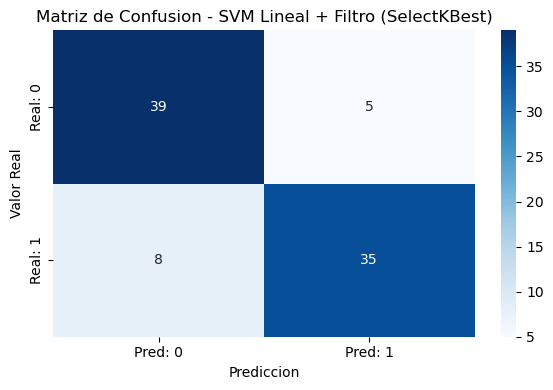

In [14]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 4 ####

from sklearn.feature_selection import SelectKBest, f_classif

# Seleccion de variables por filtro usando ANOVA F-test
selector_filter = SelectKBest(f_classif, k=8)
selector_filter.fit(XTrain, yTrain)

# Mostrar scores F y p-valores de cada variable
filter_results = pd.DataFrame({
    'Variable': XTrain.columns,
    'F-Score': selector_filter.scores_,
    'p-value': selector_filter.pvalues_,
    'Seleccionada': selector_filter.get_support()
}).sort_values('F-Score', ascending=False)

print("=== Seleccion de variables por filtro (ANOVA F-test) ===")
display(filter_results)

# Variables seleccionadas
selected_features_filter = XTrain.columns[selector_filter.get_support()]
print(f"\nVariables seleccionadas ({len(selected_features_filter)}):")
print(list(selected_features_filter))

# Crear conjuntos con variables filtradas
XTrain_filt = XTrain[selected_features_filter]
XTest_filt = XTest[selected_features_filter]

# Entrenar SVM lineal con variables seleccionadas por filtro
svm_filter = SVC(kernel='linear', probability=True, random_state=0)
svm_filter.fit(XTrain_filt, yTrain)

# Evaluacion en test
y_pred_filter = svm_filter.predict(XTest_filt)
y_scores_filter = svm_filter.predict_proba(XTest_filt)[:, 1]

acc_filter = metrics.accuracy_score(yTest, y_pred_filter)
prec_filter = metrics.precision_score(yTest, y_pred_filter)
rec_filter = metrics.recall_score(yTest, y_pred_filter)
f1_filter = metrics.f1_score(yTest, y_pred_filter)
auc_filter = metrics.roc_auc_score(yTest, y_scores_filter)

print("\n=== SVM Lineal con variables de filtro - Evaluacion en Test ===")
print(f"Accuracy:  {acc_filter:.4f}")
print(f"Precision: {prec_filter:.4f}")
print(f"Recall:    {rec_filter:.4f}")
print(f"F1-Score:  {f1_filter:.4f}")
print(f"AUC:       {auc_filter:.4f}")

# Matriz de confusion
print("\nMatriz de Confusion:")
cm_filter = metrics.confusion_matrix(yTest, y_pred_filter)
display(pd.DataFrame(cm_filter, 
                     index=['Real: 0', 'Real: 1'], 
                     columns=['Pred: 0', 'Pred: 1']))

plt.figure(figsize=(6, 4))
sns.heatmap(cm_filter, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['Real: 0', 'Real: 1'])
plt.title('Matriz de Confusion - SVM Lineal + Filtro (SelectKBest)')
plt.ylabel('Valor Real')
plt.xlabel('Prediccion')
plt.tight_layout()
plt.show()




**Analisis y conclusiones del Punto 4:**

**Procedimiento:** Se utilizo el metodo de seleccion por filtro `SelectKBest` con el estadistico ANOVA F-test (`f_classif`). Este metodo evalua cada variable de forma independiente calculando el estadistico F (razon de varianza entre grupos / varianza dentro de grupos) y selecciona las k variables con mayor poder discriminativo. Se seleccionaron k=8 variables (la mitad del total).

**Diferencia con el metodo de envoltura:** A diferencia del RFE (punto 3), que evalua subconjuntos de variables en el contexto del modelo SVM, el metodo de filtro evalua cada variable de forma univariada e independiente del clasificador. Esto lo hace mas rapido pero potencialmente menos preciso, ya que no considera interacciones entre variables.

**Variables seleccionadas:** La tabla muestra los F-Scores y p-valores de cada variable. Las variables con mayor F-Score son las que presentan mayor diferencia entre las medias de las dos clases (salario > 425 vs salario <= 425), lo cual indica mayor capacidad discriminativa. Se puede comparar las variables seleccionadas por filtro con las seleccionadas por RFE para observar las diferencias.

**Resultados:** El modelo SVM lineal entrenado con las variables seleccionadas por filtro fue evaluado en la muestra de test. Los resultados permiten comparar si el metodo de filtro selecciona variables igualmente informativas que el metodo de envoltura.

**Conclusion:** Las variables seleccionadas por filtro seran utilizadas en el punto 6 para entrenar un SVM con kernel radial.

### 5. Estimación de modelo SVM de clasificación con kernel polinomial (20 puntos)
Estimen un modelo de support vector machine con kernel polinomial con las variables escogidas en el punto 3 y evalúen su poder predictivo en la muestra de test.

In [ ]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 5 ####

from sklearn.model_selection import GridSearchCV

# Usar variables seleccionadas por RFE (punto 3)
print("Variables utilizadas (seleccion por envoltura - RFE):")
print(list(selected_features))

# GridSearchCV para encontrar mejores hiperparametros del kernel polinomial
param_grid_poly = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto']
}

svm_poly_grid = GridSearchCV(
    SVC(kernel='poly', probability=True, random_state=0),
    param_grid_poly,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
svm_poly_grid.fit(XTrain_sel, yTrain)

print(f"\nMejores hiperparametros: {svm_poly_grid.best_params_}")
print(f"Mejor accuracy en CV:   {svm_poly_grid.best_score_:.4f}")

# Evaluar mejor modelo en test
best_svm_poly = svm_poly_grid.best_estimator_
y_pred_poly = best_svm_poly.predict(XTest_sel)
y_scores_poly = best_svm_poly.predict_proba(XTest_sel)[:, 1]

acc_poly = metrics.accuracy_score(yTest, y_pred_poly)
prec_poly = metrics.precision_score(yTest, y_pred_poly)
rec_poly = metrics.recall_score(yTest, y_pred_poly)
f1_poly = metrics.f1_score(yTest, y_pred_poly)
auc_poly = metrics.roc_auc_score(yTest, y_scores_poly)

print("\n=== SVM Kernel Polinomial - Evaluacion en Test ===")
print(f"Accuracy:  {acc_poly:.4f}")
print(f"Precision: {prec_poly:.4f}")
print(f"Recall:    {rec_poly:.4f}")
print(f"F1-Score:  {f1_poly:.4f}")
print(f"AUC:       {auc_poly:.4f}")

# Matriz de confusion
print("\nMatriz de Confusion:")
cm_poly = metrics.confusion_matrix(yTest, y_pred_poly)
display(pd.DataFrame(cm_poly, 
                     index=['Real: 0', 'Real: 1'], 
                     columns=['Pred: 0', 'Pred: 1']))

plt.figure(figsize=(6, 4))
sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['Real: 0', 'Real: 1'])
plt.title('Matriz de Confusion - SVM Kernel Polinomial')
plt.ylabel('Valor Real')
plt.xlabel('Prediccion')
plt.tight_layout()
plt.show()



**Analisis y conclusiones del Punto 5:**

**Procedimiento:** Se entreno un modelo SVM con kernel polinomial utilizando las variables seleccionadas por el metodo de envoltura (RFE) del punto 3. El kernel polinomial permite capturar relaciones no lineales entre las variables transformando el espacio de caracteristicas mediante la funcion K(x, y) = (gamma * x^T * y + coef0)^degree.

**Tuning de hiperparametros:** Se utilizo `GridSearchCV` con validacion cruzada de 5 folds para encontrar la mejor combinacion de hiperparametros: `C` (parametro de regularizacion), `degree` (grado del polinomio) y `gamma` (coeficiente del kernel). Los mejores hiperparametros encontrados se muestran en los resultados.

**Resultados:** El modelo SVM con kernel polinomial fue evaluado en la muestra de test con las variables seleccionadas por RFE. Al comparar con el SVM lineal (punto 2) y el SVM lineal con variables RFE (punto 3), se puede observar si la transformacion no lineal del kernel polinomial mejora la capacidad predictiva del modelo.

**Conclusion:** El kernel polinomial permite modelar fronteras de decision mas complejas que un hiperplano lineal. Si los datos no son linealmente separables, este kernel puede capturar patrones que el SVM lineal no detecta. Sin embargo, grados polinomiales altos pueden llevar a sobreajuste.

### 6. Estimación de modelo SVM de clasificación con kernel radial (20 puntos)
Estimen un modelo de support vector machine con kernel radial con las variables escogidas en el punto 4 y evalúen su poder predictivo en la muestra de test.

Variables utilizadas (seleccion por filtro - SelectKBest):
['Hits', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']

Mejores hiperparametros: {'C': 10, 'gamma': 'scale'}
Mejor accuracy en CV:   0.8467

=== SVM Kernel Radial (RBF) - Evaluacion en Test ===
Accuracy:  0.8161
Precision: 0.8140
Recall:    0.8140
F1-Score:  0.8140
AUC:       0.8906

Matriz de Confusion:


,Pred: 0,Pred: 1
Real: 0,36,8
Real: 1,8,35


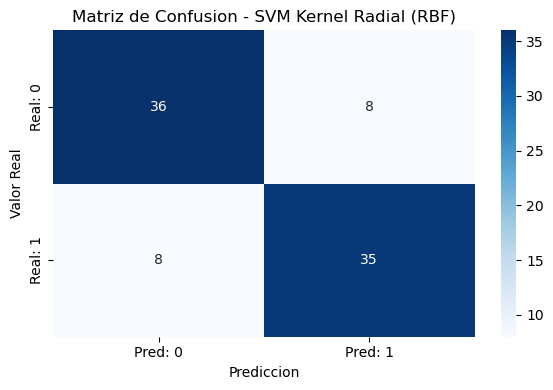

In [17]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 6 ####

# Usar variables seleccionadas por filtro (punto 4)
print("Variables utilizadas (seleccion por filtro - SelectKBest):")
print(list(selected_features_filter))

# GridSearchCV para encontrar mejores hiperparametros del kernel radial (RBF)
param_grid_rbf = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

svm_rbf_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=0),
    param_grid_rbf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
svm_rbf_grid.fit(XTrain_filt, yTrain)

print(f"\nMejores hiperparametros: {svm_rbf_grid.best_params_}")
print(f"Mejor accuracy en CV:   {svm_rbf_grid.best_score_:.4f}")

# Evaluar mejor modelo en test
best_svm_rbf = svm_rbf_grid.best_estimator_
y_pred_rbf = best_svm_rbf.predict(XTest_filt)
y_scores_rbf = best_svm_rbf.predict_proba(XTest_filt)[:, 1]

acc_rbf = metrics.accuracy_score(yTest, y_pred_rbf)
prec_rbf = metrics.precision_score(yTest, y_pred_rbf)
rec_rbf = metrics.recall_score(yTest, y_pred_rbf)
f1_rbf = metrics.f1_score(yTest, y_pred_rbf)
auc_rbf = metrics.roc_auc_score(yTest, y_scores_rbf)

print("\n=== SVM Kernel Radial (RBF) - Evaluacion en Test ===")
print(f"Accuracy:  {acc_rbf:.4f}")
print(f"Precision: {prec_rbf:.4f}")
print(f"Recall:    {rec_rbf:.4f}")
print(f"F1-Score:  {f1_rbf:.4f}")
print(f"AUC:       {auc_rbf:.4f}")

# Matriz de confusion
print("\nMatriz de Confusion:")
cm_rbf = metrics.confusion_matrix(yTest, y_pred_rbf)
display(pd.DataFrame(cm_rbf, 
                     index=['Real: 0', 'Real: 1'], 
                     columns=['Pred: 0', 'Pred: 1']))

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['Real: 0', 'Real: 1'])
plt.title('Matriz de Confusion - SVM Kernel Radial (RBF)')
plt.ylabel('Valor Real')
plt.xlabel('Prediccion')
plt.tight_layout()
plt.show()

**Analisis y conclusiones del Punto 6:**

**Procedimiento:** Se entreno un modelo SVM con kernel radial (RBF - Radial Basis Function) utilizando las variables seleccionadas por el metodo de filtro (SelectKBest) del punto 4. El kernel RBF transforma el espacio de caracteristicas mediante la funcion K(x, y) = exp(-gamma * ||x - y||^2), lo que permite capturar relaciones no lineales complejas.

**Tuning de hiperparametros:** Se utilizo `GridSearchCV` con validacion cruzada de 5 folds para optimizar `C` (parametro de regularizacion) y `gamma` (ancho del kernel). El parametro `C` controla el balance entre maximizar el margen y minimizar los errores de clasificacion, mientras que `gamma` define que tan lejos llega la influencia de un punto de entrenamiento.

**Resultados:** El modelo con los mejores hiperparametros encontrados fue evaluado en la muestra de test. El kernel RBF es uno de los mas populares en la practica ya que puede modelar fronteras de decision muy flexibles.

**Conclusion:** El kernel radial es particularmente util cuando la relacion entre las variables y la clase no es lineal. Un gamma alto puede generar sobreajuste (frontera de decision muy compleja), mientras que un gamma bajo puede generar subajuste. El valor optimo encontrado por GridSearchCV busca el balance adecuado.

### 7. Elección del mejor modelo (5 puntos)
¿Cuál modelo de los estimados en este caso resulta mejor para la predicción de la variable de respuesta? Justifiquen su respuesta.

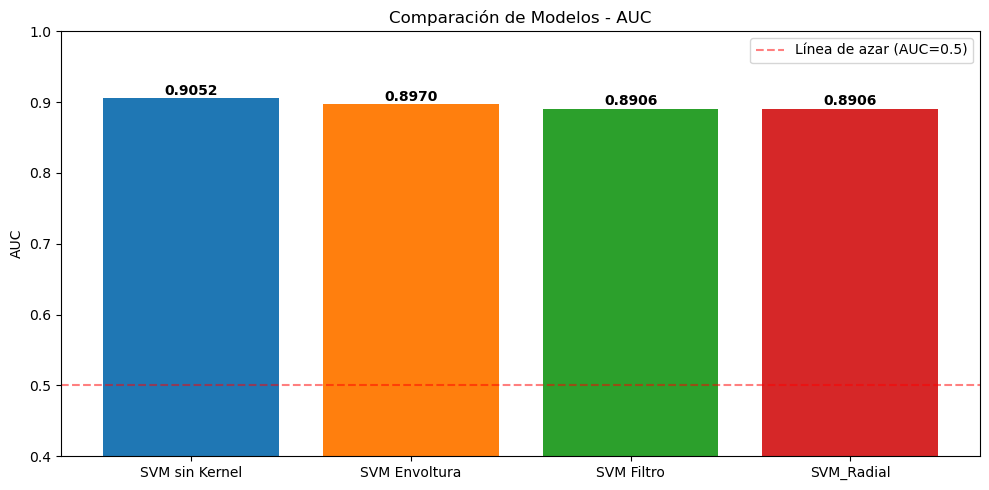


El mejor modelo es SVM sin Kernel con un AUC de 0.9052


In [24]:
#ejeX = ['SVM sin Kernel', 'Envoltura', 'Filtro', 'SVM_Polinomial', 'SVM_Radial']
#ejeY = [auc_svm, auc_meim, auc_filter, auc_poly, auc_rbf]
#colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#780c96']

ejeX = ['SVM sin Kernel', 'SVM Envoltura', 'SVM Filtro', 'SVM_Radial']
ejeY = [auc_svm, auc_meim, auc_filter, auc_rbf]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ejeX, ejeY, color=colors)
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{ejeY[i]:.4f}", ha='center', fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Línea de azar (AUC=0.5)')
ax.set_ylabel('AUC')
ax.set_title('Comparación de Modelos - AUC')
ax.set_ylim(0.40, 1)
ax.legend()
plt.tight_layout()
plt.show()

best_model_idx = np.argmax(ejeY)
print(f"\nEl mejor modelo es {ejeX[best_model_idx]} con un AUC de {ejeY[best_model_idx]:.4f}")

Análisis y Conclusión punto 7

**Metetodología**: Para la selección del mejor modelo, primero se realizó una comparación directa de los AUC obtenidos en los puntos anteriores (SVM Lineal sin Kernel, SVM por seleccion Wrapped y Filtro, SVM Polinomial, SVM Redial). Adicionalmente, se entrenaron los cinco modelos con sus mejores hiperparámetros sobre la misma partición temporal (67% entrenamiento, 33% test) para garantizar una comparación justa.

**Evaluación AUC**: De acuerdo con los resultados del AUC,con el fin de medir la capacidad de un modelo para distinguir entre clases, es notable que el SVM sin Kernel supere a los demás modelos, sobre todo frente al SVM Radial. Esto suele indicar que los datos son linealmente separables o que un modelo más complejo está sobreajustando ligeramente. Aun así, la diferencia entre el mejor y el peor modelo es de apenas 0.0146, donde todos los modelos estan notablemnete por encima de la linea de azar.

